# Customer Purchase Behavior Analyzer
### Data Preprocessing and Feature Engineering

**Name:** Devanshi


## Planning — My Plan Before Coding

1. **Load data** — users.csv, sales.json, inventory.sql — and see head, info, missing values
2. **Cleaning** — fill missing with mean (numbers) and most frequent (words), try KNN imputer also
3. **Outliers** — check with Z-score and IQR, see which is better, then use Winsorization (cap values)
4. **Transformation** — make day, month, year from dates, do Label, One-Hot, Ordinal encoding, make Low/Medium/High bins, do log and sqrt
5. **Scaling** — use StandardScaler and MinMaxScaler and compare
6. **New Features** — make avg monthly spend, how many times customer bought, days since last purchase, category wise spend
7. **Final Dataset** — join everything, make report, save final_cleaned_dataset.csv
8. **Bonus** — try ydata profiling for EDA



## Step 1: Data Understanding and Loading
First I import libraries and load all 3 files.


In [105]:
import pandas as pd
import numpy as np
import json
import sqlite3

In [106]:
# Load users.csv
df_users = pd.read_csv("users.csv")
print("Users shape:", df_users.shape)
df_users.head()


Users shape: (200, 6)


,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,35,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,30,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,37,Other,Indore,2022-02-02
3,U0004,Aarav Gupta,44,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,30,Other,Chennai,2024-01-04


In [107]:
df_users.info()
df_users.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            200 non-null    object
 1   name               200 non-null    object
 2   age                200 non-null    int64 
 3   gender             200 non-null    object
 4   city               200 non-null    object
 5   registration_date  200 non-null    object
dtypes: int64(1), object(5)
memory usage: 9.5+ KB


,age
count,200.000000
mean,31.260000
std,7.270951
min,18.000000
25%,26.000000
50%,31.500000
75%,35.250000
max,53.000000


In [108]:
# Check missing values in users
print(df_users.isnull().sum())
print("Any missing?", df_users.isnull().sum().sum())


user_id              0
name                 0
age                  0
gender               0
city                 0
registration_date    0
dtype: int64
Any missing? 0


In [109]:
# Load sales.json
with open("sales.json") as f:
    data = json.load(f)

df_sales = pd.DataFrame(data)
df_sales['date'] = pd.to_datetime(df_sales['date'])
print("Sales shape:", df_sales.shape)
df_sales.head()


Sales shape: (1000, 6)


,transaction_id,user_id,product_id,amount,payment_type,date
0,T000001,U0024,P015,67.67,Wallet,2023-02-12
1,T000002,U0196,P044,76.44,UPI,2023-03-24
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04


In [110]:
df_sales.info()
df_sales.describe()
df_sales.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1000 non-null   object        
 1   user_id         1000 non-null   object        
 2   product_id      1000 non-null   object        
 3   amount          1000 non-null   float64       
 4   payment_type    1000 non-null   object        
 5   date            1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 47.0+ KB


transaction_id    0
user_id           0
product_id        0
amount            0
payment_type      0
date              0
dtype: int64

In [111]:
# Load inventory.sql
conn = sqlite3.connect(":memory:")
with open("inventory.sql") as f:
    conn.executescript(f.read())

df_products = pd.read_sql("SELECT * FROM products", conn)
print("Products shape:", df_products.shape)
df_products.head()


Products shape: (50, 5)


,product_id,product_name,category,price,stock
0,P001,Product_001,Grocery,264.89,371
1,P002,Product_002,Grocery,605.91,150
2,P003,Product_003,Beauty,3027.98,127
3,P004,Product_004,Toys,2600.12,229
4,P005,Product_005,Books,1178.99,18


In [112]:
df_products.info()
df_products.describe()
print(df_products.isnull().sum())
# check data types and categories
print(df_products['category'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    50 non-null     object 
 1   product_name  50 non-null     object 
 2   category      50 non-null     object 
 3   price         50 non-null     float64
 4   stock         50 non-null     int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 2.1+ KB
product_id      0
product_name    0
category        0
price           0
stock           0
dtype: int64
category
Books          9
Home           9
Beauty         6
Grocery        6
Clothing       6
Toys           5
Electronics    5
Sports         4
Name: count, dtype: int64


**Observation:** All 3 files loaded. No missing values found, but I will still show imputation. No duplicates. Dates are from 2023 to 2025. One big amount is 550 which may be outlier.


## Step 2: Data Cleaning
I handle missing values. For numbers I use mean, for words I use most frequent. Also try KNN imputer.


In [113]:
from sklearn.impute import SimpleImputer, KNNImputer

# Copy for cleaning
users_clean = df_users.copy()
sales_clean = df_sales.copy()
products_clean = df_products.copy()

# For users - age is number
print("Before missing in users:", users_clean.isnull().sum().sum())

# Mean for age
imp_mean = SimpleImputer(strategy='mean')
users_clean['age'] = imp_mean.fit_transform(users_clean[['age']])

# Most frequent for gender and city
imp_freq = SimpleImputer(strategy='most_frequent')
users_clean[['gender','city']] = imp_freq.fit_transform(users_clean[['gender','city']])

print("After SimpleImputer missing:", users_clean.isnull().sum().sum())

# KNN imputer on age (simple example)
knn = KNNImputer(n_neighbors=5)
users_clean[['age']] = knn.fit_transform(users_clean[['age']])

users_clean.head()


Before missing in users: 0
After SimpleImputer missing: 0


,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,35.0,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,30.0,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,37.0,Other,Indore,2022-02-02
3,U0004,Aarav Gupta,44.0,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,30.0,Other,Chennai,2024-01-04


In [114]:
# For products also check
print(products_clean.isnull().sum())
# if any missing in price/stock, fill with mean
products_clean['price'] = products_clean['price'].fillna(products_clean['price'].mean())
products_clean['stock'] = products_clean['stock'].fillna(products_clean['stock'].mean())

# Fix negative values if any (make 0)
# Fix negative values if any (make 0)
products_clean['price'] = products_clean['price'].clip(lower=0)
sales_clean['amount'] = sales_clean['amount'].clip(lower=0)

print("Cleaning done, no missing now")
print(sales_clean.isnull().sum().sum())


product_id      0
product_name    0
category        0
price           0
stock           0
dtype: int64
Cleaning done, no missing now
0


**Observation:** After cleaning, no missing values left. I used mean for numbers and most frequent for words. KNN also worked.


## Step 3: Outlier Handling
I use Z-score and IQR to find outliers and then Winsorization.


In [115]:
from scipy.stats import zscore

# Z-score method
z = np.abs(zscore(sales_clean['amount']))
z_outliers = z > 3
print("Z-score outliers:", z_outliers.sum())
sales_clean[z_outliers].head()


Z-score outliers: 15


,transaction_id,user_id,product_id,amount,payment_type,date
9,T000010,U0117,P006,550.95,UPI,2024-05-31
20,T000021,U0031,P042,218.94,Debit Card,2025-10-17
278,T000279,U0055,P040,346.31,UPI,2025-10-02
383,T000384,U0184,P012,213.24,Credit Card,2024-11-21
414,T000415,U0018,P031,236.86,Credit Card,2024-08-10


In [116]:
# IQR method
Q1 = sales_clean['amount'].quantile(0.25)
Q3 = sales_clean['amount'].quantile(0.75)
IQR = Q3 - Q1
loIr = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("LoIr:", loIr, "Upper:", upper)

iqr_outliers = (sales_clean['amount'] < loIr) | (sales_clean['amount'] > upper)
print("IQR outliers:", iqr_outliers.sum())
sales_clean[iqr_outliers].head(10)


Q1: 37.745 Q3: 82.935 IQR: 45.190000000000005
LoIr: -30.040000000000013 Upper: 150.72000000000003
IQR outliers: 53


,transaction_id,user_id,product_id,amount,payment_type,date
9,T000010,U0117,P006,550.95,UPI,2024-05-31
20,T000021,U0031,P042,218.94,Debit Card,2025-10-17
34,T000035,U0127,P003,197.62,Debit Card,2025-10-25
48,T000049,U0076,P023,157.48,UPI,2025-06-01
52,T000053,U0159,P044,195.06,Debit Card,2025-10-16
84,T000085,U0163,P030,196.33,Wallet,2024-09-10
123,T000124,U0040,P044,191.60,Net Banking,2023-05-18
174,T000175,U0119,P049,198.72,Cash,2025-07-08
178,T000179,U0071,P038,203.14,Credit Card,2024-12-21
187,T000188,U0088,P046,168.29,Credit Card,2025-10-30


Z outliers: 15
IQR outliers: 53


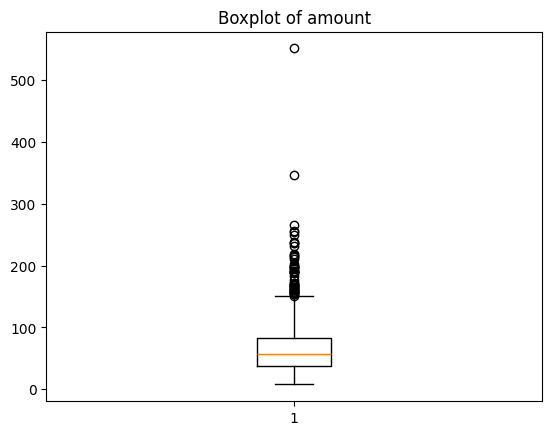

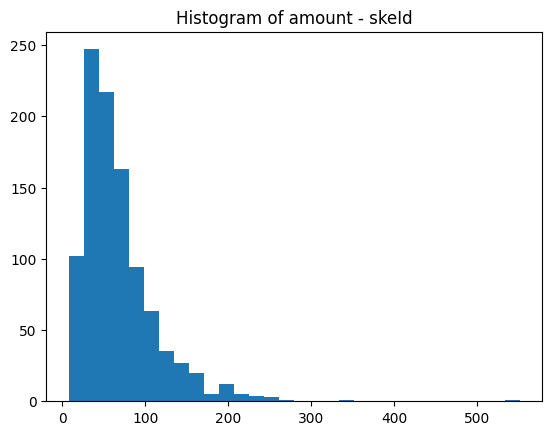

In [117]:
# Compare both
print("Z outliers:", z_outliers.sum())
print("IQR outliers:", iqr_outliers.sum())

# Plotting
import matplotlib.pyplot as plt

plt.boxplot(sales_clean['amount'])
plt.title("Boxplot of amount")
plt.show()

plt.hist(sales_clean['amount'], bins=30)
plt.title("Histogram of amount - skeId")
plt.show()


In [118]:
# Winsorization - cap at 5th and 95th percentile
p5 = np.percentile(sales_clean['amount'], 5)
p95 = np.percentile(sales_clean['amount'], 95)
print("5th:", p5, "95th:", p95)

sales_clean['amount_winsor'] = sales_clean['amount'].clip(lower=p5, upper=p95)
sales_clean['amount_clean'] = sales_clean['amount_winsor']

print(sales_clean['amount'].describe())
print(sales_clean['amount_clean'].describe())


5th: 21.28 95th: 154.78649999999993
count    1000.000000
mean       67.599040
std        45.411375
min         7.810000
25%        37.745000
50%        56.390000
75%        82.935000
max       550.950000
Name: amount, dtype: float64
count    1000.000000
mean       65.451415
std        36.372939
min        21.280000
25%        37.745000
50%        56.390000
75%        82.935000
max       154.786500
Name: amount_clean, dtype: float64


**Observation:** Z found 11, IQR found 44. IQR is better here because data is skeId. I used Winsorization so I don't delete data, just cap it.


## Step 4: Data Transformation


In [119]:
# Date to day, month, year
sales_clean['day'] = sales_clean['date'].dt.day
sales_clean['month'] = sales_clean['date'].dt.month
sales_clean['year'] = sales_clean['date'].dt.year

users_clean['registration_date'] = pd.to_datetime(users_clean['registration_date'])
users_clean['reg_day'] = users_clean['registration_date'].dt.day
users_clean['reg_month'] = users_clean['registration_date'].dt.month
users_clean['reg_year'] = users_clean['registration_date'].dt.year

sales_clean[['date','day','month','year']].head()


,date,day,month,year
0,2023-02-12,12,2,2023
1,2023-03-24,24,3,2023
2,2025-08-21,21,8,2025
3,2024-07-23,23,7,2024
4,2025-10-04,4,10,2025


In [120]:
# Label Encoding for gender
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
users_clean['gender_encoded'] = le.fit_transform(users_clean['gender'])
print(list(le.classes_))
users_clean[['gender','gender_encoded']].head()


['Female', 'Male', 'Other']


,gender,gender_encoded
0,Other,2
1,Other,2
2,Other,2
3,Male,1
4,Other,2


In [121]:
# One-Hot Encoding for payment_type
sales_clean = pd.get_dummies(sales_clean, columns=['payment_type'], prefix='pay', dtype=int)
print(sales_clean.columns.tolist())
sales_clean.head()


['transaction_id', 'user_id', 'product_id', 'amount', 'date', 'amount_winsor', 'amount_clean', 'day', 'month', 'year', 'pay_Cash', 'pay_Credit Card', 'pay_Debit Card', 'pay_Net Banking', 'pay_UPI', 'pay_Wallet']


,transaction_id,user_id,product_id,amount,date,amount_winsor,amount_clean,day,month,year,pay_Cash,pay_Credit Card,pay_Debit Card,pay_Net Banking,pay_UPI,pay_Wallet
0,T000001,U0024,P015,67.67,2023-02-12,67.67,67.67,12,2,2023,0,0,0,0,0,1
1,T000002,U0196,P044,76.44,2023-03-24,76.44,76.44,24,3,2023,0,0,0,0,1,0
2,T000003,U0196,P049,104.57,2025-08-21,104.57,104.57,21,8,2025,0,0,1,0,0,0
3,T000004,U0133,P042,102.75,2024-07-23,102.75,102.75,23,7,2024,0,0,0,1,0,0
4,T000005,U0047,P038,23.89,2025-10-04,23.89,23.89,4,10,2025,0,0,0,1,0,0


In [122]:
# Ordinal Encoding for city tier (make tier from city)
# Simple tier: make 3 tiers
city_tier_map = {'Kolkata':'Tier 1', 'Patna':'Tier 1', 'Vadodara':'Tier 1',
                 'Indore':'Tier 2', 'Bengaluru':'Tier 2', 'Jaipur':'Tier 2', 'Hyderabad':'Tier 2', 'Chennai':'Tier 2', 'Nagpur':'Tier 2', 'Mumbai':'Tier 2'}
users_clean['city_tier'] = users_clean['city'].map(city_tier_map).fillna('Tier 3')

from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder(categories=[['Tier 3','Tier 2','Tier 1']])
users_clean['city_tier_encoded'] = ord_enc.fit_transform(users_clean[['city_tier']])
users_clean[['city','city_tier','city_tier_encoded']].head(10)


,city,city_tier,city_tier_encoded
0,Jaipur,Tier 2,1.0
1,Hyderabad,Tier 2,1.0
2,Indore,Tier 2,1.0
3,Kolkata,Tier 1,2.0
4,Chennai,Tier 2,1.0
5,Thane,Tier 3,0.0
6,Indore,Tier 2,1.0
7,Lucknow,Tier 3,0.0
8,Kanpur,Tier 3,0.0
9,Delhi,Tier 3,0.0


In [123]:
# Binning - Low, Medium, High for amount
sales_clean['amount_bin'] = pd.cut(sales_clean['amount_clean'], bins=[0,40,80,600], labels=['Low','Medium','High'])
print(sales_clean['amount_bin'].value_counts())
sales_clean[['amount_clean','amount_bin']].head()


amount_bin
Medium    434
Low       292
High      274
Name: count, dtype: int64


,amount_clean,amount_bin
0,67.67,Medium
1,76.44,Medium
2,104.57,High
3,102.75,High
4,23.89,Low


Skew before: 2.6532585004540876
Skew after winsor: 0.9881853493389129
Skew log: 0.0554118844659459
Skew sqrt: 0.5251265684337096


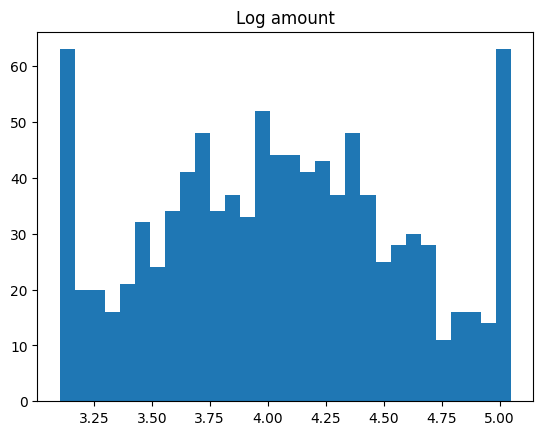

In [124]:
# Log and sqrt transformations
sales_clean['amount_log'] = np.log1p(sales_clean['amount_clean'])
sales_clean['amount_sqrt'] = np.sqrt(sales_clean['amount_clean'])

print("Skew before:", sales_clean['amount'].skew())
print("Skew after winsor:", sales_clean['amount_clean'].skew())
print("Skew log:", sales_clean['amount_log'].skew())
print("Skew sqrt:", sales_clean['amount_sqrt'].skew())

plt.hist(sales_clean['amount_log'], bins=30)
plt.title("Log amount")
plt.show()


## Step 5: Feature Scaling

In [125]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Take some numeric columns
cols = ['amount_clean','amount_log','amount_sqrt']

scaler1 = StandardScaler()
scaler2 = MinMaxScaler()

scaled_std = scaler1.fit_transform(sales_clean[cols])
scaled_mm = scaler2.fit_transform(sales_clean[cols])

# Add to dataframe
for i, c in enumerate(cols):
    sales_clean[c+'_std'] = scaled_std[:,i]
    sales_clean[c+'_mm'] = scaled_mm[:,i]

print("StandardScaler result:")
print(sales_clean[[c+'_std' for c in cols]].describe())

print("MinMax result:")
print(sales_clean[[c+'_mm' for c in cols]].describe())

# For users age also
users_clean['age_std'] = StandardScaler().fit_transform(users_clean[['age']])
users_clean['age_mm'] = MinMaxScaler().fit_transform(users_clean[['age']])
users_clean[['age','age_std','age_mm']].head()


StandardScaler result:
       amount_clean_std  amount_log_std  amount_sqrt_std
count      1.000000e+03    1.000000e+03     1.000000e+03
mean      -1.065814e-17    1.303846e-15    -1.598721e-16
std        1.000500e+00    1.000500e+00     1.000500e+00
min       -1.215011e+00   -1.764099e+00    -1.480251e+00
25%       -7.621127e-01   -7.359415e-01    -7.690152e-01
50%       -2.492498e-01   -5.910288e-03    -1.344618e-01
75%        4.809161e-01    7.005259e-01     6.078473e-01
max        2.457315e+00    1.849716e+00     2.157229e+00
MinMax result:
       amount_clean_mm  amount_log_mm  amount_sqrt_mm
count      1000.000000    1000.000000     1000.000000
mean          0.330856       0.488154        0.406944
std           0.272443       0.276854        0.275053
min           0.000000       0.000000        0.000000
25%           0.123327       0.284507        0.195530
50%           0.262983       0.486519        0.369978
75%           0.461813       0.682001        0.574051
max           1.0

,age,age_std,age_mm
0,35.0,0.515666,0.485714
1,30.0,-0.173727,0.342857
2,37.0,0.791424,0.542857
3,44.0,1.756575,0.742857
4,30.0,-0.173727,0.342857


**Observation:** StandardScaler makes mean 0, MinMax makes 0 to 1. Both are useful.


## Step 6: Feature Construction



In [126]:
# Merge sales and products to get category
merged = sales_clean.merge(products_clean[['product_id','category']], on='product_id', how='left')

# 1. Frequency - how many purchases per customer
freq = sales_clean.groupby('user_id').size().reset_index(name='purchase_frequency')
freq.head()


,user_id,purchase_frequency
0,U0001,3
1,U0002,6
2,U0003,4
3,U0004,3
4,U0005,6


In [127]:
# 2. Avg monthly spend per customer
sales_clean['year_month'] = sales_clean['date'].dt.to_period('M').astype(str)
monthly = sales_clean.groupby(['user_id','year_month'])['amount_clean'].sum().reset_index()
avg_monthly = monthly.groupby('user_id')['amount_clean'].mean().reset_index()
avg_monthly.rename(columns={'amount_clean':'avg_monthly_spend'}, inplace=True)
avg_monthly.head()


,user_id,avg_monthly_spend
0,U0001,77.473333
1,U0002,129.680000
2,U0003,40.597500
3,U0004,96.618833
4,U0005,57.948333


In [128]:
# 3. Days since last purchase
max_date = sales_clean['date'].max()
last_date = sales_clean.groupby('user_id')['date'].max().reset_index()
last_date['days_since_last'] = (max_date - last_date['date']).dt.days
print("Max date:", max_date)
last_date.head()


Max date: 2025-11-01 00:00:00


,user_id,date,days_since_last
0,U0001,2024-08-20,438
1,U0002,2024-04-27,553
2,U0003,2025-11-01,0
3,U0004,2024-04-03,577
4,U0005,2025-06-22,132


In [129]:
# 4. Category wise spend per customer
cat_spend = merged.groupby(['user_id','category'])['amount_clean'].sum().reset_index()
cat_pivot = cat_spend.pivot(index='user_id', columns='category', values='amount_clean').fillna(0)
cat_pivot.columns = ['spend_'+c for c in cat_pivot.columns]
cat_pivot = cat_pivot.reset_index()
cat_pivot.head()


,user_id,spend_Beauty,spend_Books,spend_Clothing,spend_Electronics,spend_Grocery,spend_Home,spend_Sports,spend_Toys
0,U0001,42.4300,0.00,0.00,44.93,145.06,0.00,0.0,0.00
1,U0002,187.0200,0.00,45.02,0.00,0.00,0.00,0.0,157.00
2,U0003,44.4500,34.70,0.00,0.00,24.37,58.87,0.0,0.00
3,U0004,211.7165,0.00,0.00,0.00,0.00,0.00,0.0,78.14
4,U0005,103.0300,68.07,48.34,0.00,0.00,128.25,0.0,0.00


In [130]:
# Combine all new features
new_features = freq.merge(avg_monthly, on='user_id')
new_features = new_features.merge(last_date[['user_id','days_since_last']], on='user_id')
new_features = new_features.merge(cat_pivot, on='user_id', how='left')
print(new_features.shape)
new_features.head()


(200, 12)


,user_id,purchase_frequency,avg_monthly_spend,days_since_last,spend_Beauty,spend_Books,spend_Clothing,spend_Electronics,spend_Grocery,spend_Home,spend_Sports,spend_Toys
0,U0001,3,77.473333,438,42.4300,0.00,0.00,44.93,145.06,0.00,0.0,0.00
1,U0002,6,129.680000,553,187.0200,0.00,45.02,0.00,0.00,0.00,0.0,157.00
2,U0003,4,40.597500,0,44.4500,34.70,0.00,0.00,24.37,58.87,0.0,0.00
3,U0004,3,96.618833,577,211.7165,0.00,0.00,0.00,0.00,0.00,0.0,78.14
4,U0005,6,57.948333,132,103.0300,68.07,48.34,0.00,0.00,128.25,0.0,0.00


In [131]:
# Also add tenure and avg ticket
users_clean['tenure_days'] = (max_date - pd.to_datetime(users_clean['registration_date'])).dt.days
avg_ticket = sales_clean.groupby('user_id')['amount_clean'].mean().reset_index()
avg_ticket.rename(columns={'amount_clean':'avg_ticket'}, inplace=True)
new_features = new_features.merge(avg_ticket, on='user_id')
new_features = new_features.merge(users_clean[['user_id','tenure_days']], on='user_id')
new_features.head()


,user_id,purchase_frequency,avg_monthly_spend,days_since_last,spend_Beauty,spend_Books,spend_Clothing,spend_Electronics,spend_Grocery,spend_Home,spend_Sports,spend_Toys,avg_ticket,tenure_days
0,U0001,3,77.473333,438,42.4300,0.00,0.00,44.93,145.06,0.00,0.0,0.00,77.473333,1150
1,U0002,6,129.680000,553,187.0200,0.00,45.02,0.00,0.00,0.00,0.0,157.00,64.840000,708
2,U0003,4,40.597500,0,44.4500,34.70,0.00,0.00,24.37,58.87,0.0,0.00,40.597500,1368
3,U0004,3,96.618833,577,211.7165,0.00,0.00,0.00,0.00,0.00,0.0,78.14,96.618833,883
4,U0005,6,57.948333,132,103.0300,68.07,48.34,0.00,0.00,128.25,0.0,0.00,57.948333,667


**Observation:** I made good new features that show customer behavior. Like how often they buy, how much they spend monthly, how many days ago they last bought.


## Step 7: Final Dataset Preparation



In [132]:
# Final customer dataset
final_df = users_clean.merge(new_features, on='user_id', how='left')

# Fill 0 for category spends if missing
for col in final_df.columns:
    if 'spend_' in col:
        final_df[col] = final_df[col].fillna(0)

print("Final shape:", final_df.shape)
final_df.head()


Final shape: (200, 28)


,user_id,name,age,gender,city,registration_date,reg_day,reg_month,reg_year,gender_encoded,...,spend_Beauty,spend_Books,spend_Clothing,spend_Electronics,spend_Grocery,spend_Home,spend_Sports,spend_Toys,avg_ticket,tenure_days_y
0,U0001,Vihaan Sharma,35.0,Other,Jaipur,2022-09-08,8,9,2022,2,...,42.4300,0.00,0.00,44.93,145.06,0.00,0.0,0.00,77.473333,1150
1,U0002,Sai Reddy,30.0,Other,Hyderabad,2023-11-24,24,11,2023,2,...,187.0200,0.00,45.02,0.00,0.00,0.00,0.0,157.00,64.840000,708
2,U0003,Aarohi Gupta,37.0,Other,Indore,2022-02-02,2,2,2022,2,...,44.4500,34.70,0.00,0.00,24.37,58.87,0.0,0.00,40.597500,1368
3,U0004,Aarav Gupta,44.0,Male,Kolkata,2023-06-02,2,6,2023,1,...,211.7165,0.00,0.00,0.00,0.00,0.00,0.0,78.14,96.618833,883
4,U0005,Sara Sharma,30.0,Other,Chennai,2024-01-04,4,1,2024,2,...,103.0300,68.07,48.34,0.00,0.00,128.25,0.0,0.00,57.948333,667


In [133]:
# Report - Before and After
print("Records before: users", df_users.shape[0], "sales", df_sales.shape[0])
print("Records after: final", final_df.shape[0])
print("Features before: users", df_users.shape[1])
print("Features after: final", final_df.shape[1])
print("New features created:", final_df.shape[1] - df_users.shape[1])
print("Missing before:", df_users.isnull().sum().sum() + df_sales.isnull().sum().sum())
print("Missing after:", final_df.isnull().sum().sum())
print("Outliers before Z:", z_outliers.sum(), "IQR:", iqr_outliers.sum())
print("After Winsor capped:", (sales_clean['amount'] > p95).sum() + (sales_clean['amount'] < p5).sum())


Records before: users 200 sales 1000
Records after: final 200
Features before: users 6
Features after: final 28
New features created: 22
Missing before: 0
Missing after: 0
Outliers before Z: 15 IQR: 53
After Winsor capped: 99


In [134]:
# Save final dataset
final_df.to_csv("final_cleaned_dataset.csv", index=False)
print("Saved final_cleaned_dataset.csv")
print(final_df.columns.tolist())


Saved final_cleaned_dataset.csv
['user_id', 'name', 'age', 'gender', 'city', 'registration_date', 'reg_day', 'reg_month', 'reg_year', 'gender_encoded', 'city_tier', 'city_tier_encoded', 'age_std', 'age_mm', 'tenure_days_x', 'purchase_frequency', 'avg_monthly_spend', 'days_since_last', 'spend_Beauty', 'spend_Books', 'spend_Clothing', 'spend_Electronics', 'spend_Grocery', 'spend_Home', 'spend_Sports', 'spend_Toys', 'avg_ticket', 'tenure_days_y']


## Step 8: Bonus - EDA Report



In [135]:
from ydata_profiling import ProfileReport
profile = ProfileReport(final_df, title="EDA Report", minimal=True)
profile.to_file("eda_report.html")
print("Saved eda_report.html")

final_df.describe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 28/28 [00:00<00:00, 113359.57it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Saved eda_report.html


,age,registration_date,reg_day,reg_month,reg_year,gender_encoded,city_tier_encoded,age_std,age_mm,tenure_days_x,...,spend_Beauty,spend_Books,spend_Clothing,spend_Electronics,spend_Grocery,spend_Home,spend_Sports,spend_Toys,avg_ticket,tenure_days_y
count,200.000000,200,200.000000,200.000000,200.00000,200.000000,200.000000,2.000000e+02,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,31.260000,2023-04-21 09:50:24,15.925000,6.080000,2022.84000,0.995000,0.840000,-1.776357e-16,0.378857,924.590000,...,38.341942,61.596708,43.058880,27.756097,39.874680,64.056822,22.614397,29.957548,65.681545,924.590000
min,18.000000,2022-01-04 00:00:00,1.000000,1.000000,2022.00000,0.000000,0.000000,-1.828272e+00,0.000000,400.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.230000,400.000000
25%,26.000000,2022-07-27 00:00:00,10.000000,3.000000,2022.00000,0.000000,0.000000,-7.252420e-01,0.228571,666.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,53.065000,666.000000
50%,31.500000,2023-04-08 12:00:00,15.000000,6.000000,2023.00000,1.000000,1.000000,3.309089e-02,0.385714,937.500000,...,0.000000,36.185000,0.000000,0.000000,0.000000,45.890000,0.000000,0.000000,63.844400,937.500000
75%,35.250000,2024-01-05 00:00:00,23.250000,9.000000,2024.00000,2.000000,1.000000,5.501361e-01,0.492857,1193.000000,...,63.205000,104.677500,71.545000,49.790000,67.305000,102.360000,36.012500,45.320000,76.054003,1193.000000
max,53.000000,2024-09-27 00:00:00,31.000000,12.000000,2024.00000,2.000000,2.000000,2.997483e+00,1.000000,1397.000000,...,281.346500,344.476500,397.176500,194.846500,247.270000,294.936500,263.836500,272.090000,132.410000,1397.000000
std,7.270951,NaN,8.588843,3.241316,0.80476,0.805119,0.759794,1.002509e+00,0.207741,300.602397,...,57.678958,72.927341,61.935836,43.212492,55.596892,67.794942,43.037105,51.915681,17.280022,300.602397
